In [1]:
!pip -q install torchmetrics[image] torch-fidelity thop

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 24.4 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import json
import math
import time
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, random_split, Subset

import torchvision
import torchvision.transforms as T
from torchvision import datasets
from torchvision.utils import save_image, make_grid

from torchmetrics.image.fid import FrechetInceptionDistance
from thop import profile

In [4]:
# -----------------------------
# Main experiment configuration
# -----------------------------
CFG = {
    "seed": 42,

    # Paths
    "project_root": "/content/drive/MyDrive/CSE499B_Lightweight_Diffusion/cifar10_compare",
    "data_root": "/content/data",

    # Data
    "image_size": 32,
    "channels": 3,
    "train_batch_size": 128,
    "eval_batch_size": 128,
    "num_workers": 2,
    "val_size": 5000,          # from CIFAR10 train split

    # Training
    "epochs": 30,              # for quick faculty demo; later increase to 100
    "lr": 2e-4,
    "weight_decay": 1e-4,
    "grad_clip": 1.0,
    "ema_decay": 0.999,
    "sample_every": 5,         # save samples every N epochs

    # Diffusion
    "timesteps": 1000,
    "beta_start": 1e-4,
    "beta_end": 2e-2,

    # Sampling
    "num_sample_grid": 16,
    "ddim_steps_eval": 50,
    "ddim_eta": 0.0,

    # Evaluation
    "speed_num_images": 64,
    "fid_real_images": 2000,   # increase later for final report
    "fid_fake_images": 2000,

    # Optional quick mode
    "train_limit": None,       # e.g. set 10000 for faster testing
}

In [5]:
# -----------------------------
# Create folders and set seeds
# -----------------------------
project_root = Path(CFG["project_root"])
ckpt_dir = project_root / "checkpoints"
sample_dir = project_root / "samples"
result_dir = project_root / "results"

for p in [project_root, ckpt_dir, sample_dir, result_dir]:
    p.mkdir(parents=True, exist_ok=True)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(CFG["seed"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

Device: cuda


In [6]:
# ---------------------------------
# CIFAR-10 transforms and dataloaders
# ---------------------------------
# Training transform: light augmentation
train_transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),   # maps [0,1] -> [-1,1]
])

# Validation / test transform: no augmentation
eval_transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# Base datasets
full_train_aug = datasets.CIFAR10(root=CFG["data_root"], train=True, download=True, transform=train_transform)
full_train_eval = datasets.CIFAR10(root=CFG["data_root"], train=True, download=False, transform=eval_transform)
test_ds = datasets.CIFAR10(root=CFG["data_root"], train=False, download=True, transform=eval_transform)

# Fixed train/val split
g = torch.Generator().manual_seed(CFG["seed"])
indices = torch.randperm(len(full_train_aug), generator=g).tolist()
val_indices = indices[:CFG["val_size"]]
train_indices = indices[CFG["val_size"]:]

train_ds = Subset(full_train_aug, train_indices)
val_ds = Subset(full_train_eval, val_indices)

# Optional quick subset for faster debugging
if CFG["train_limit"] is not None:
    train_ds = Subset(train_ds, list(range(min(CFG["train_limit"], len(train_ds)))))

train_loader = DataLoader(
    train_ds,
    batch_size=CFG["train_batch_size"],
    shuffle=True,
    num_workers=CFG["num_workers"],
    pin_memory=torch.cuda.is_available(),
    drop_last=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=CFG["eval_batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_ds,
    batch_size=CFG["eval_batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=torch.cuda.is_available()
)

print("Train size:", len(train_ds))
print("Val size  :", len(val_ds))
print("Test size :", len(test_ds))

100%|██████████| 170M/170M [00:05<00:00, 33.9MB/s]


Train size: 45000
Val size  : 5000
Test size : 10000


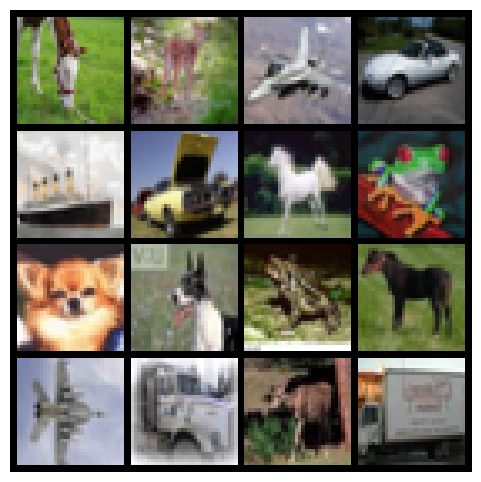

In [7]:
# -----------------------------
# Visualize some CIFAR-10 images
# -----------------------------
xb, yb = next(iter(train_loader))
grid = make_grid(xb[:16], nrow=4, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0).cpu())
plt.axis("off")
plt.show()

In [8]:
# -----------------------------
# Helper functions
# -----------------------------
def count_params(model):
    """Return number of trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def to_uint8_from_minus1_1(x):
    """Convert tensor from [-1,1] float to [0,1] float for metrics."""
    return ((x + 1.0) / 2.0).clamp(0.0, 1.0)

def save_tensor_grid(x, path, nrow=4):
    """Save a grid of images from [-1,1] range."""
    save_image(x, path, nrow=nrow, normalize=True, value_range=(-1, 1))

def make_group_norm(num_channels):
    """Choose a valid GroupNorm group count automatically."""
    for g in [32, 16, 8, 4, 2, 1]:
        if num_channels % g == 0:
            return nn.GroupNorm(g, num_channels)
    return nn.GroupNorm(1, num_channels)

In [9]:
# ---------------------------------------
# Sinusoidal timestep embedding and blocks
# ---------------------------------------
class SinusoidalPosEmb(nn.Module):
    """Sinusoidal time-step embedding."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2
        emb_factor = math.log(10000) / max(half_dim - 1, 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb_factor)
        emb = t[:, None].float() * emb[None, :]
        emb = torch.cat([emb.sin(), emb.cos()], dim=1)
        return emb

class ResBlock(nn.Module):
    """Residual block with timestep conditioning."""
    def __init__(self, in_ch, out_ch, time_dim, dropout=0.1):
        super().__init__()
        self.norm1 = make_group_norm(in_ch)
        self.act1 = nn.SiLU()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)

        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_dim, out_ch)
        )

        self.norm2 = make_group_norm(out_ch)
        self.act2 = nn.SiLU()
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)

        self.skip = nn.Conv2d(in_ch, out_ch, kernel_size=1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(self.act1(self.norm1(x)))
        h = h + self.time_mlp(t_emb)[:, :, None, None]
        h = self.conv2(self.dropout(self.act2(self.norm2(h))))
        return h + self.skip(x)

In [ ]:
# -----------------------------
# Lightweight / baseline U-Net
# -----------------------------
class SimpleUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, base_channels=64, dropout=0.1):
        super().__init__()
        time_dim = base_channels * 4

        # Time embedding
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(base_channels),
            nn.Linear(base_channels, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim)
        )

        # Input projection
        self.in_conv = nn.Conv2d(in_channels, base_channels, kernel_size=3, padding=1)

        # Encoder
        self.enc1 = ResBlock(base_channels, base_channels, time_dim, dropout)
        self.down1 = nn.Conv2d(base_channels, base_channels, kernel_size=4, stride=2, padding=1)

        self.enc2 = ResBlock(base_channels, base_channels * 2, time_dim, dropout)
        self.down2 = nn.Conv2d(base_channels * 2, base_channels * 2, kernel_size=4, stride=2, padding=1)

        self.enc3 = ResBlock(base_channels * 2, base_channels * 4, time_dim, dropout)
        self.down3 = nn.Conv2d(base_channels * 4, base_channels * 4, kernel_size=4, stride=2, padding=1)

        # Bottleneck
        self.mid1 = ResBlock(base_channels * 4, base_channels * 4, time_dim, dropout)
        self.mid2 = ResBlock(base_channels * 4, base_channels * 4, time_dim, dropout)

        # Decoder
        self.up3 = nn.ConvTranspose2d(base_channels * 4, base_channels * 4, kernel_size=4, stride=2, padding=1)
        self.dec3 = ResBlock(base_channels * 8, base_channels * 2, time_dim, dropout)

        self.up2 = nn.ConvTranspose2d(base_channels * 2, base_channels * 2, kernel_size=4, stride=2, padding=1)
        self.dec2 = ResBlock(base_channels * 4, base_channels, time_dim, dropout)

        self.up1 = nn.ConvTranspose2d(base_channels, base_channels, kernel_size=4, stride=2, padding=1)
        self.dec1 = ResBlock(base_channels * 2, base_channels, time_dim, dropout)

        # Output head
        self.out_norm = make_group_norm(base_channels)
        self.out_act = nn.SiLU()
        self.out_conv = nn.Conv2d(base_channels, out_channels, kernel_size=3, padding=1)

    def forward(self, x, t):
        t_emb = self.time_mlp(t)

        # Input
        x0 = self.in_conv(x)

        # Encoder
        x1 = self.enc1(x0, t_emb)                 # 32x32
        x2 = self.enc2(self.down1(x1), t_emb)    # 16x16
        x3 = self.enc3(self.down2(x2), t_emb)    # 8x8

        # Bottleneck
        h = self.down3(x3)                       # 4x4
        h = self.mid1(h, t_emb)
        h = self.mid2(h, t_emb)

        # Decoder
        h = self.up3(h)                          # 8x8
        h = torch.cat([h, x3], dim=1)
        h = self.dec3(h, t_emb)

        h = self.up2(h)                          # 16x16
        h = torch.cat([h, x2], dim=1)
        h = self.dec2(h, t_emb)

        h = self.up1(h)                          # 32x32
        h = torch.cat([h, x1], dim=1)
        h = self.dec1(h, t_emb)

        # Output
        return self.out_conv(self.out_act(self.out_norm(h)))

In [10]:
# -----------------------------
# Diffusion schedule and buffers
# -----------------------------
T_steps = CFG["timesteps"]

betas = torch.linspace(CFG["beta_start"], CFG["beta_end"], T_steps, device=device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)

In [11]:
# -----------------------------
# EMA helper
# -----------------------------
@torch.no_grad()
def update_ema(ema_model, model, decay=0.999):
    """
    Update EMA weights.
    """
    msd = model.state_dict()
    for k, v in ema_model.state_dict().items():
        if v.dtype.is_floating_point:
            v.copy_(v * decay + msd[k].detach() * (1.0 - decay))
        else:
            v.copy_(msd[k])

In [12]:
# -----------------------------
# Evaluation utilities
# -----------------------------
@torch.no_grad()
def evaluate_noise_loss(model, loader):
    """Compute average noise-prediction loss on validation data."""
    model.eval()
    total_loss = 0.0
    total_count = 0

    for x, _ in loader:
        x = x.to(device, non_blocking=True)
        t = torch.randint(0, T_steps, (x.size(0),), device=device).long()
        loss = p_losses(model, x, t)
        total_loss += loss.item() * x.size(0)
        total_count += x.size(0)

    return total_loss / total_count

@torch.no_grad()
def save_epoch_samples(model, out_path, sample_steps=50, n=16):
    """Generate and save a sample grid."""
    samples = sample_ddim(
        model,
        n=n,
        img_size=CFG["image_size"],
        channels=CFG["channels"],
        sample_steps=sample_steps,
        eta=CFG["ddim_eta"]
    )
    save_tensor_grid(samples, out_path, nrow=4)

@torch.no_grad()
def measure_ddim_speed(model, num_images=64, sample_steps=50, batch_size=64):
    """
    Measure average seconds/image for DDIM sampling.
    """
    model.eval()
    n_done = 0
    total_time = 0.0

    while n_done < num_images:
        bs = min(batch_size, num_images - n_done)

        if device.type == "cuda":
            torch.cuda.synchronize()

        start = time.time()
        _ = sample_ddim(
            model,
            n=bs,
            img_size=CFG["image_size"],
            channels=CFG["channels"],
            sample_steps=sample_steps,
            eta=CFG["ddim_eta"]
        )

        if device.type == "cuda":
            torch.cuda.synchronize()

        total_time += time.time() - start
        n_done += bs

    return total_time / num_images

def profile_model_macs_params(model):
    """
    Profile MACs with THOP and parameter count.
    """
    model.eval()
    dummy_x = torch.randn(1, CFG["channels"], CFG["image_size"], CFG["image_size"], device=device)
    dummy_t = torch.randint(0, T_steps, (1,), device=device).long()

    macs, params_thop = profile(model, inputs=(dummy_x, dummy_t), verbose=False)
    params_count = count_params(model)

    return macs, params_count, params_thop

@torch.no_grad()
def compute_fid_ddim(model, real_loader, n_real=2000, n_fake=2000, sample_steps=50):
    """
    Compute FID using TorchMetrics.
    Uses EMA model and DDIM-generated samples.
    """
    fid = FrechetInceptionDistance(normalize=True).to(device)
    model.eval()

    # Real images
    real_seen = 0
    for x, _ in real_loader:
        x = x.to(device, non_blocking=True)
        x = to_uint8_from_minus1_1(x)

        if real_seen + x.size(0) > n_real:
            x = x[: n_real - real_seen]

        fid.update(x, real=True)
        real_seen += x.size(0)

        if real_seen >= n_real:
            break

    # Fake images
    fake_seen = 0
    while fake_seen < n_fake:
        bs = min(real_loader.batch_size, n_fake - fake_seen)
        fake = sample_ddim(
            model,
            n=bs,
            img_size=CFG["image_size"],
            channels=CFG["channels"],
            sample_steps=sample_steps,
            eta=CFG["ddim_eta"]
        )
        fake = to_uint8_from_minus1_1(fake)
        fid.update(fake, real=False)
        fake_seen += bs

    return float(fid.compute().item())

In [13]:
# -----------------------------
# Train one model
# -----------------------------
def train_model(model_name, base_channels):
    print(f"\n========== Training: {model_name} | base_channels={base_channels} ==========")

    # Build model
    model = SimpleUNet(
        in_channels=CFG["channels"],
        out_channels=CFG["channels"],
        base_channels=base_channels,
        dropout=0.1
    ).to(device)

    # EMA copy
    ema_model = copy.deepcopy(model).to(device)
    ema_model.eval()
    for p in ema_model.parameters():
        p.requires_grad_(False)

    # Optimizer and scheduler
    optimizer = AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
    scheduler = CosineAnnealingLR(optimizer, T_max=CFG["epochs"])
    scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

    # Tracking
    history = []
    best_val = float("inf")

    model_ckpt_dir = ckpt_dir / model_name
    model_sample_dir = sample_dir / model_name
    model_result_dir = result_dir / model_name

    model_ckpt_dir.mkdir(parents=True, exist_ok=True)
    model_sample_dir.mkdir(parents=True, exist_ok=True)
    model_result_dir.mkdir(parents=True, exist_ok=True)

    for epoch in range(1, CFG["epochs"] + 1):
        model.train()
        running_loss = 0.0
        seen = 0

        start_epoch = time.time()

        for x, _ in train_loader:
            x = x.to(device, non_blocking=True)
            t = torch.randint(0, T_steps, (x.size(0),), device=device).long()

            optimizer.zero_grad(set_to_none=True)

            with torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
                loss = p_losses(model, x, t)

            scaler.scale(loss).backward()

            if CFG["grad_clip"] is not None:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), CFG["grad_clip"])

            scaler.step(optimizer)
            scaler.update()

            # EMA update after optimizer step
            update_ema(ema_model, model, decay=CFG["ema_decay"])

            running_loss += loss.item() * x.size(0)
            seen += x.size(0)

        scheduler.step()

        train_loss = running_loss / seen
        val_loss = evaluate_noise_loss(model, val_loader)
        epoch_time = time.time() - start_epoch
        lr_now = optimizer.param_groups[0]["lr"]

        # Save latest checkpoint
        latest_ckpt = model_ckpt_dir / f"{model_name}_latest_full.pt"
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "ema_state_dict": ema_model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "train_loss": train_loss,
            "val_loss": val_loss,
            "base_channels": base_channels,
            "config": CFG,
        }, latest_ckpt)

        # Save best checkpoint
        if val_loss < best_val:
            best_val = val_loss
            best_ckpt = model_ckpt_dir / f"{model_name}_best_full.pt"
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "ema_state_dict": ema_model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "train_loss": train_loss,
                "val_loss": val_loss,
                "base_channels": base_channels,
                "config": CFG,
            }, best_ckpt)

        # Save milestone checkpoint every 10 epochs
        if epoch % 10 == 0:
            milestone_ckpt = model_ckpt_dir / f"{model_name}_epoch{epoch}.pt"
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "ema_state_dict": ema_model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "train_loss": train_loss,
                "val_loss": val_loss,
                "base_channels": base_channels,
                "config": CFG,
            }, milestone_ckpt)

        # Save samples every few epochs using EMA model
        if epoch % CFG["sample_every"] == 0 or epoch == 1 or epoch == CFG["epochs"]:
            sample_path = model_sample_dir / f"{model_name}_epoch{epoch:03d}_ddim{CFG['ddim_steps_eval']}.png"
            save_epoch_samples(
                ema_model,
                sample_path,
                sample_steps=CFG["ddim_steps_eval"],
                n=CFG["num_sample_grid"]
            )

        # Store logs
        log_item = {
            "epoch": epoch,
            "train_loss": float(train_loss),
            "val_loss": float(val_loss),
            "lr": float(lr_now),
            "epoch_time_sec": float(epoch_time),
        }
        history.append(log_item)

        with open(model_result_dir / f"{model_name}_trainlog.json", "w") as f:
            json.dump(history, f, indent=2)

        print(
            f"[{model_name}] Epoch {epoch:03d}/{CFG['epochs']} | "
            f"train_loss={train_loss:.6f} | val_loss={val_loss:.6f} | "
            f"lr={lr_now:.6e} | time={epoch_time:.1f}s"
        )

    # Save final log CSV
    hist_df = pd.DataFrame(history)
    hist_df.to_csv(model_result_dir / f"{model_name}_trainlog.csv", index=False)

    return model, ema_model, history

In [15]:
# -----------------------------
# Train baseline model
# base_channels = 64
# -----------------------------

if "SimpleUNet" not in globals():
    raise NameError("SimpleUNet is not defined. Please run the U-Net model definition cell first.")

if "train_model" not in globals():
    raise NameError("train_model is not defined. Please run the training function cell first.")

baseline_model, baseline_ema, baseline_hist = train_model(
    model_name="baseline_cifar10",
    base_channels=64
)

NameError: SimpleUNet is not defined. Please run the U-Net model definition cell first.

In [16]:
# =========================
# FIXED MODEL DEFINITION CELL
# Run this BEFORE train_model(...)
# =========================

import math
import torch
import torch.nn as nn

def make_group_norm(num_channels):
    """
    Return a valid GroupNorm for any channel size.
    """
    for g in [32, 16, 8, 4, 2, 1]:
        if num_channels % g == 0:
            return nn.GroupNorm(g, num_channels)
    return nn.GroupNorm(1, num_channels)

class SinusoidalPosEmb(nn.Module):
    """
    Sinusoidal timestep embedding.
    Input: t of shape [B]
    Output: embedding of shape [B, dim]
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        emb_scale = math.log(10000) / max(half_dim - 1, 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb_scale)
        emb = t[:, None].float() * emb[None, :]
        emb = torch.cat([emb.sin(), emb.cos()], dim=1)
        return emb

class ResBlock(nn.Module):
    """
    Residual block with timestep conditioning.
    """
    def __init__(self, in_ch, out_ch, time_dim, dropout=0.1):
        super().__init__()

        self.norm1 = make_group_norm(in_ch)
        self.act1 = nn.SiLU()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)

        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_dim, out_ch)
        )

        self.norm2 = make_group_norm(out_ch)
        self.act2 = nn.SiLU()
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)

        self.skip = nn.Conv2d(in_ch, out_ch, kernel_size=1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(self.act1(self.norm1(x)))
        h = h + self.time_mlp(t_emb)[:, :, None, None]
        h = self.conv2(self.dropout(self.act2(self.norm2(h))))
        return h + self.skip(x)

class SimpleUNet(nn.Module):
    """
    Simple diffusion U-Net for CIFAR-10.
    baseline: base_channels=64
    lightweight: base_channels=32
    """
    def __init__(self, in_channels=3, out_channels=3, base_channels=64, dropout=0.1):
        super().__init__()

        time_dim = base_channels * 4

        # Time embedding
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(base_channels),
            nn.Linear(base_channels, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim)
        )

        # Input
        self.in_conv = nn.Conv2d(in_channels, base_channels, kernel_size=3, padding=1)

        # Encoder
        self.enc1 = ResBlock(base_channels, base_channels, time_dim, dropout)                 # 32x32
        self.down1 = nn.Conv2d(base_channels, base_channels, kernel_size=4, stride=2, padding=1)

        self.enc2 = ResBlock(base_channels, base_channels * 2, time_dim, dropout)             # 16x16
        self.down2 = nn.Conv2d(base_channels * 2, base_channels * 2, kernel_size=4, stride=2, padding=1)

        self.enc3 = ResBlock(base_channels * 2, base_channels * 4, time_dim, dropout)         # 8x8
        self.down3 = nn.Conv2d(base_channels * 4, base_channels * 4, kernel_size=4, stride=2, padding=1)

        # Bottleneck
        self.mid1 = ResBlock(base_channels * 4, base_channels * 4, time_dim, dropout)         # 4x4
        self.mid2 = ResBlock(base_channels * 4, base_channels * 4, time_dim, dropout)

        # Decoder
        self.up3 = nn.ConvTranspose2d(base_channels * 4, base_channels * 4, kernel_size=4, stride=2, padding=1)
        self.dec3 = ResBlock(base_channels * 8, base_channels * 2, time_dim, dropout)

        self.up2 = nn.ConvTranspose2d(base_channels * 2, base_channels * 2, kernel_size=4, stride=2, padding=1)
        self.dec2 = ResBlock(base_channels * 4, base_channels, time_dim, dropout)

        self.up1 = nn.ConvTranspose2d(base_channels, base_channels, kernel_size=4, stride=2, padding=1)
        self.dec1 = ResBlock(base_channels * 2, base_channels, time_dim, dropout)

        # Output
        self.out_norm = make_group_norm(base_channels)
        self.out_act = nn.SiLU()
        self.out_conv = nn.Conv2d(base_channels, out_channels, kernel_size=3, padding=1)

    def forward(self, x, t):
        t_emb = self.time_mlp(t)

        # Input
        x0 = self.in_conv(x)

        # Encoder
        x1 = self.enc1(x0, t_emb)                    # [B, C, 32, 32]
        x2 = self.enc2(self.down1(x1), t_emb)       # [B, 2C, 16, 16]
        x3 = self.enc3(self.down2(x2), t_emb)       # [B, 4C, 8, 8]

        # Bottleneck
        h = self.down3(x3)                          # [B, 4C, 4, 4]
        h = self.mid1(h, t_emb)
        h = self.mid2(h, t_emb)

        # Decoder
        h = self.up3(h)                             # [B, 4C, 8, 8]
        h = torch.cat([h, x3], dim=1)
        h = self.dec3(h, t_emb)

        h = self.up2(h)                             # [B, 2C, 16, 16]
        h = torch.cat([h, x2], dim=1)
        h = self.dec2(h, t_emb)

        h = self.up1(h)                             # [B, C, 32, 32]
        h = torch.cat([h, x1], dim=1)
        h = self.dec1(h, t_emb)

        return self.out_conv(self.out_act(self.out_norm(h)))

print("SimpleUNet is now defined successfully.")

SimpleUNet is now defined successfully.


In [18]:
# DIFFUSION HELPER CELL
# Run this BEFORE train_model(...)
# =========================

import torch
import torch.nn.functional as F

# Make sure CFG, device, and T_steps already exist
T_steps = CFG["timesteps"]

# Diffusion schedule
betas = torch.linspace(CFG["beta_start"], CFG["beta_end"], T_steps, device=device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)

def extract(a, t, x_shape):
    """
    Extract values from 1D tensor a using indices t,
    then reshape for broadcasting.
    """
    out = a.gather(-1, t)
    return out.reshape(t.shape[0], *((1,) * (len(x_shape) - 1)))

def q_sample(x_start, t, noise=None):
    """
    Forward diffusion:
    x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1-alpha_bar_t) * noise
    """
    if noise is None:
        noise = torch.randn_like(x_start)

    sqrt_alpha_bar_t = extract(sqrt_alphas_cumprod, t, x_start.shape)
    sqrt_one_minus_alpha_bar_t = extract(sqrt_one_minus_alphas_cumprod, t, x_start.shape)

    return sqrt_alpha_bar_t * x_start + sqrt_one_minus_alpha_bar_t * noise

def p_losses(model, x_start, t, noise=None):
    """
    Training loss:
    model predicts the added noise
    """
    if noise is None:
        noise = torch.randn_like(x_start)

    x_noisy = q_sample(x_start=x_start, t=t, noise=noise)
    pred_noise = model(x_noisy, t)
    loss = F.mse_loss(pred_noise, noise)
    return loss

@torch.no_grad()
def p_sample(model, x, t, t_index):
    """
    Sample one timestep from the model's predicted distribution. (DDPM)
    """
    betas_t = extract(betas, t, x.shape)
    sqrt_one_minus_alphas_cumprod_t = extract(
        sqrt_one_minus_alphas_cumprod, t, x.shape
    )
    sqrt_recip_alphas_t = extract(sqrt_recip_alphas, t, x.shape)

    # Equation 11 in https://arxiv.org/pdf/2006.11239.pdf
    # Epsilon (noise) predicted by model
    model_mean = sqrt_recip_alphas_t * (
        x - betas_t * model(x, t) / sqrt_one_minus_alphas_cumprod_t
    )
    # if t is last step, then no noise
    if t_index == 0:
        return model_mean
    else:
        posterior_variance_t = extract(posterior_variance, t, x.shape)
        noise = torch.randn_like(x)
        return model_mean + torch.sqrt(posterior_variance_t) * noise


@torch.no_grad()
def p_sample_loop(model, shape):
    """
    Generate images using the sampling loop (DDPM).
    """
    img_b, img_c, img_h, img_w = shape
    img = torch.randn(shape, device=device)
    for t in reversed(range(0, T_steps)):
        t_tensor = torch.full((img_b,), t, device=device, dtype=torch.long)
        img = p_sample(model, img, t_tensor, t)
    return img


@torch.no_grad()
def sample_ddim(model, n, img_size, channels, sample_steps=50, eta=0.0):
    """
    Generate images using DDIM sampling.
    """
    c = channels
    h = img_size
    w = img_size
    shape = (n, c, h, w)

    # Get times for DDIM sampling
    skip = T_steps // sample_steps
    seq = range(0, T_steps, skip)
    seq_next = [-1, *list(seq[:-1])]

    x = torch.randn(shape, device=device)
    for i, j in tqdm(enumerate(reversed(seq)), total=len(seq), desc='DDIM sampling'):
        t = (torch.ones(n) * j).long().to(device)
        next_t = (torch.ones(n) * seq_next[i+1]).long().to(device)
        at = extract(alphas_cumprod, t, x.shape)
        at_next = extract(alphas_cumprod, next_t, x.shape)

        xt = x
        et = model(xt, t)

        if at_next.item() == -1.0: # for the case when next_t is -1
            x0_t = (xt - torch.sqrt(1 - at) * et) / torch.sqrt(at)
        else:
            x0_t = (xt - torch.sqrt(1 - at) * et) / torch.sqrt(at)
            c1 = eta * torch.sqrt((1 - at / at_next) * (1 - at) / (1 - at))
            c2 = torch.sqrt((1 - at_next) - c1**2)
            x = torch.sqrt(at_next) * x0_t + c2 * et + c1 * torch.randn_like(x)

    return x


print("Diffusion helper functions are now defined successfully.")

Diffusion helper functions are now defined successfully.


In [20]:
# =========================================================
# FULL FIX CELL
# Paste this AFTER dataset loaders + SimpleUNet cell
# =========================================================

import os
import json
import time
import copy
from pathlib import Path

import torch
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision.utils import save_image

# -----------------------------
# Safety checks
# -----------------------------
required_names = ["CFG", "device", "train_loader", "val_loader", "SimpleUNet"]
for name in required_names:
    if name not in globals():
        raise NameError(f"{name} is not defined. Please run the earlier cell that creates it first.")

# -----------------------------
# Output folders
# -----------------------------
project_root = Path(CFG["project_root"])
ckpt_dir = project_root / "checkpoints"
sample_dir = project_root / "samples"
result_dir = project_root / "results"

for p in [project_root, ckpt_dir, sample_dir, result_dir]:
    p.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Utility helpers
# -----------------------------
def save_tensor_grid(x, path, nrow=4):
    """
    Save image grid from tensor in [-1, 1] range.
    """
    save_image(x, path, nrow=nrow, normalize=True, value_range=(-1, 1))

# -----------------------------
# Diffusion schedule
# -----------------------------
T_steps = CFG["timesteps"]

betas = torch.linspace(CFG["beta_start"], CFG["beta_end"], T_steps, device=device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)

# -----------------------------
# Diffusion helper functions
# -----------------------------
def extract(a, t, x_shape):
    """
    Extract values from 1D tensor a at indices t
    and reshape for broadcasting.
    """
    out = a.gather(-1, t)
    return out.reshape(t.shape[0], *((1,) * (len(x_shape) - 1)))

def q_sample(x_start, t, noise=None):
    """
    Forward diffusion:
    x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1-alpha_bar_t) * noise
    """
    if noise is None:
        noise = torch.randn_like(x_start)

    sqrt_alpha_bar_t = extract(sqrt_alphas_cumprod, t, x_start.shape)
    sqrt_one_minus_alpha_bar_t = extract(sqrt_one_minus_alphas_cumprod, t, x_start.shape)

    return sqrt_alpha_bar_t * x_start + sqrt_one_minus_alpha_bar_t * noise

def p_losses(model, x_start, t, noise=None):
    """
    Training loss:
    model predicts the added noise.
    """
    if noise is None:
        noise = torch.randn_like(x_start)

    x_noisy = q_sample(x_start=x_start, t=t, noise=noise)
    pred_noise = model(x_noisy, t)
    loss = F.mse_loss(pred_noise, noise)
    return loss

@torch.no_grad()
def p_sample(model, x, t):
    """
    One reverse DDPM step.
    """
    betas_t = extract(betas, t, x.shape)
    sqrt_one_minus_t = extract(sqrt_one_minus_alphas_cumprod, t, x.shape)
    sqrt_recip_alpha_t = extract(sqrt_recip_alphas, t, x.shape)

    pred_noise = model(x, t)
    model_mean = sqrt_recip_alpha_t * (x - betas_t * pred_noise / sqrt_one_minus_t)

    posterior_var_t = extract(posterior_variance, t, x.shape)
    noise = torch.randn_like(x)

    nonzero_mask = (t != 0).float().reshape(x.shape[0], *((1,) * (len(x.shape) - 1)))
    return model_mean + nonzero_mask * torch.sqrt(posterior_var_t) * noise

@torch.no_grad()
def sample_ddpm(model, n, img_size=32, channels=3):
    """
    Full DDPM sampling.
    """
    model.eval()
    x = torch.randn(n, channels, img_size, img_size, device=device)

    for i in reversed(range(T_steps)):
        t = torch.full((n,), i, device=device, dtype=torch.long)
        x = p_sample(model, x, t)

    return x.clamp(-1, 1)

@torch.no_grad()
def sample_ddim(model, n, img_size=32, channels=3, sample_steps=50, eta=0.0):
    """
    DDIM sampling.
    eta=0.0 -> deterministic DDIM
    """
    model.eval()
    x = torch.randn(n, channels, img_size, img_size, device=device)

    seq = torch.linspace(0, T_steps - 1, steps=sample_steps, device=device).long()

    for i in reversed(range(len(seq))):
        t_cur = seq[i].item()
        t_prev = -1 if i == 0 else seq[i - 1].item()

        t = torch.full((n,), t_cur, device=device, dtype=torch.long)
        eps = model(x, t)

        alpha_t = alphas_cumprod[t_cur]
        alpha_prev = torch.tensor(1.0, device=device) if t_prev < 0 else alphas_cumprod[t_prev]

        x0_pred = (x - torch.sqrt(1.0 - alpha_t) * eps) / torch.sqrt(alpha_t)
        x0_pred = x0_pred.clamp(-1, 1)

        sigma = eta * torch.sqrt((1 - alpha_prev) / (1 - alpha_t) * (1 - alpha_t / alpha_prev))
        c = torch.sqrt(torch.clamp(1 - alpha_prev - sigma**2, min=0.0))

        noise = torch.randn_like(x) if i > 0 else torch.zeros_like(x)
        x = torch.sqrt(alpha_prev) * x0_pred + c * eps + sigma * noise

    return x.clamp(-1, 1)

# -----------------------------
# EMA helper
# -----------------------------
@torch.no_grad()
def update_ema(ema_model, model, decay=0.999):
    """
    Update EMA weights.
    """
    msd = model.state_dict()
    for k, v in ema_model.state_dict().items():
        if v.dtype.is_floating_point:
            v.copy_(v * decay + msd[k].detach() * (1.0 - decay))
        else:
            v.copy_(msd[k])

# -----------------------------
# Validation + sample saving
# -----------------------------
@torch.no_grad()
def evaluate_noise_loss(model, loader):
    """
    Average validation noise prediction loss.
    """
    model.eval()
    total_loss = 0.0
    total_count = 0

    for x, _ in loader:
        x = x.to(device, non_blocking=True)
        t = torch.randint(0, T_steps, (x.size(0),), device=device).long()
        loss = p_losses(model, x, t)

        total_loss += loss.item() * x.size(0)
        total_count += x.size(0)

    return total_loss / max(total_count, 1)

@torch.no_grad()
def save_epoch_samples(model, out_path, sample_steps=50, n=16):
    """
    Generate and save a sample grid.
    """
    samples = sample_ddim(
        model,
        n=n,
        img_size=CFG["image_size"],
        channels=CFG["channels"],
        sample_steps=sample_steps,
        eta=CFG["ddim_eta"]
    )
    save_tensor_grid(samples, out_path, nrow=4)

# -----------------------------
# Main training function
# -----------------------------
def train_model(model_name, base_channels):
    print(f"\n========== Training: {model_name} | base_channels={base_channels} ==========")

    model = SimpleUNet(
        in_channels=CFG["channels"],
        out_channels=CFG["channels"],
        base_channels=base_channels,
        dropout=0.1
    ).to(device)

    ema_model = copy.deepcopy(model).to(device)
    ema_model.eval()
    for p in ema_model.parameters():
        p.requires_grad_(False)

    optimizer = AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
    scheduler = CosineAnnealingLR(optimizer, T_max=CFG["epochs"])
    scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

    history = []
    best_val = float("inf")

    model_ckpt_dir = ckpt_dir / model_name
    model_sample_dir = sample_dir / model_name
    model_result_dir = result_dir / model_name

    model_ckpt_dir.mkdir(parents=True, exist_ok=True)
    model_sample_dir.mkdir(parents=True, exist_ok=True)
    model_result_dir.mkdir(parents=True, exist_ok=True)

    for epoch in range(1, CFG["epochs"] + 1):
        model.train()
        running_loss = 0.0
        seen = 0
        start_time = time.time()

        for x, _ in train_loader:
            x = x.to(device, non_blocking=True)
            t = torch.randint(0, T_steps, (x.size(0),), device=device).long()

            optimizer.zero_grad(set_to_none=True)

            with torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
                loss = p_losses(model, x, t)

            scaler.scale(loss).backward()

            if CFG.get("grad_clip", None) is not None:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), CFG["grad_clip"])

            scaler.step(optimizer)
            scaler.update()

            update_ema(ema_model, model, decay=CFG["ema_decay"])

            running_loss += loss.item() * x.size(0)
            seen += x.size(0)

        scheduler.step()

        train_loss = running_loss / max(seen, 1)
        val_loss = evaluate_noise_loss(model, val_loader)
        epoch_time = time.time() - start_time
        current_lr = optimizer.param_groups[0]["lr"]

        latest_ckpt = model_ckpt_dir / f"{model_name}_latest_full.pt"
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "ema_state_dict": ema_model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "train_loss": train_loss,
            "val_loss": val_loss,
            "base_channels": base_channels,
            "config": CFG,
        }, latest_ckpt)

        if val_loss < best_val:
            best_val = val_loss
            best_ckpt = model_ckpt_dir / f"{model_name}_best_full.pt"
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "ema_state_dict": ema_model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "train_loss": train_loss,
                "val_loss": val_loss,
                "base_channels": base_channels,
                "config": CFG,
            }, best_ckpt)

        if epoch % 10 == 0:
            milestone_ckpt = model_ckpt_dir / f"{model_name}_epoch{epoch}.pt"
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "ema_state_dict": ema_model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "train_loss": train_loss,
                "val_loss": val_loss,
                "base_channels": base_channels,
                "config": CFG,
            }, milestone_ckpt)

        if epoch % CFG["sample_every"] == 0 or epoch == 1 or epoch == CFG["epochs"]:
            sample_path = model_sample_dir / f"{model_name}_epoch{epoch:03d}_ddim{CFG['ddim_steps_eval']}.png"
            save_epoch_samples(
                ema_model,
                sample_path,
                sample_steps=CFG["ddim_steps_eval"],
                n=CFG["num_sample_grid"]
            )

        history.append({
            "epoch": epoch,
            "train_loss": float(train_loss),
            "val_loss": float(val_loss),
            "lr": float(current_lr),
            "epoch_time_sec": float(epoch_time),
        })

        with open(model_result_dir / f"{model_name}_trainlog.json", "w") as f:
            json.dump(history, f, indent=2)

        print(
            f"[{model_name}] Epoch {epoch:03d}/{CFG['epochs']} | "
            f"train_loss={train_loss:.6f} | val_loss={val_loss:.6f} | "
            f"lr={current_lr:.6e} | time={epoch_time:.1f}s"
        )

    return model, ema_model, history

print("All helper functions + train_model are now defined successfully.")

All helper functions + train_model are now defined successfully.


In [21]:
# -----------------------------
# Train lightweight model
# base_channels = 32
# -----------------------------
light_model, light_ema, light_hist = train_model(
    model_name="lightweight_cifar10",
    base_channels=32
)


========== Training: lightweight_cifar10 | base_channels=32 ==========
[lightweight_cifar10] Epoch 001/30 | train_loss=0.189258 | val_loss=0.077894 | lr=1.994522e-04 | time=24.7s
[lightweight_cifar10] Epoch 002/30 | train_loss=0.073271 | val_loss=0.055145 | lr=1.978148e-04 | time=25.7s
[lightweight_cifar10] Epoch 003/30 | train_loss=0.058936 | val_loss=0.052935 | lr=1.951057e-04 | time=25.7s
[lightweight_cifar10] Epoch 004/30 | train_loss=0.052518 | val_loss=0.046015 | lr=1.913545e-04 | time=24.8s
[lightweight_cifar10] Epoch 005/30 | train_loss=0.047511 | val_loss=0.045466 | lr=1.866025e-04 | time=26.1s
[lightweight_cifar10] Epoch 006/30 | train_loss=0.047325 | val_loss=0.042395 | lr=1.809017e-04 | time=26.1s
[lightweight_cifar10] Epoch 007/30 | train_loss=0.044153 | val_loss=0.041566 | lr=1.743145e-04 | time=26.0s
[lightweight_cifar10] Epoch 008/30 | train_loss=0.042955 | val_loss=0.040248 | lr=1.669131e-04 | time=25.1s
[lightweight_cifar10] Epoch 009/30 | train_loss=0.041084 | val_l

In [23]:
# ==========================================
# SAFE CHECKPOINT FINDER + LOADER
# ==========================================
import copy
import torch
from pathlib import Path

project_root = Path(CFG["project_root"])
ckpt_dir = project_root / "checkpoints"

print("Checkpoint root:", ckpt_dir)

if ckpt_dir.exists():
    print("\nAvailable checkpoint folders/files:")
    for p in sorted(ckpt_dir.rglob("*")):
        print(p)
else:
    print("Checkpoint directory does not exist yet.")

def find_checkpoint_path(model_name, prefer="best"):
    """
    Try to find a checkpoint file safely.
    Returns Path or None.
    """
    model_ckpt_dir = ckpt_dir / model_name

    if not model_ckpt_dir.exists():
        return None

    best_path = model_ckpt_dir / f"{model_name}_best_full.pt"
    latest_path = model_ckpt_dir / f"{model_name}_latest_full.pt"

    if prefer == "best":
        if best_path.exists():
            return best_path
        if latest_path.exists():
            return latest_path
    else:
        if latest_path.exists():
            return latest_path
        if best_path.exists():
            return best_path

    # fallback: try any .pt file inside the folder
    pt_files = sorted(model_ckpt_dir.glob("*.pt"))
    if len(pt_files) > 0:
        return pt_files[-1]

    return None

def load_saved_model_if_exists(model_name, base_channels, prefer="best"):
    """
    Load checkpoint if it exists, otherwise return None.
    """
    ckpt_path = find_checkpoint_path(model_name, prefer=prefer)

    if ckpt_path is None:
        print(f"[SKIP] No checkpoint found for {model_name}")
        return None, None, None

    print(f"[LOAD] {model_name} -> {ckpt_path}")

    ckpt = torch.load(ckpt_path, map_location=device)

    model = SimpleUNet(
        in_channels=CFG["channels"],
        out_channels=CFG["channels"],
        base_channels=base_channels,
        dropout=0.1
    ).to(device)

    ema_model = copy.deepcopy(model).to(device)

    model.load_state_dict(ckpt["model_state_dict"])
    ema_model.load_state_dict(ckpt["ema_state_dict"])

    model.eval()
    ema_model.eval()

    print(f"Loaded {model_name} from epoch {ckpt.get('epoch', 'N/A')} | val_loss={ckpt.get('val_loss', 'N/A')}")
    return model, ema_model, ckpt

baseline_model, baseline_ema, baseline_ckpt = load_saved_model_if_exists(
    "baseline_cifar10", 64, prefer="best"
)

light_model, light_ema, light_ckpt = load_saved_model_if_exists(
    "lightweight_cifar10", 32, prefer="best"
)

Checkpoint root: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/cifar10_compare/checkpoints

Available checkpoint folders/files:
/content/drive/MyDrive/CSE499B_Lightweight_Diffusion/cifar10_compare/checkpoints/lightweight_cifar10
/content/drive/MyDrive/CSE499B_Lightweight_Diffusion/cifar10_compare/checkpoints/lightweight_cifar10/lightweight_cifar10_best_full.pt
/content/drive/MyDrive/CSE499B_Lightweight_Diffusion/cifar10_compare/checkpoints/lightweight_cifar10/lightweight_cifar10_epoch10.pt
/content/drive/MyDrive/CSE499B_Lightweight_Diffusion/cifar10_compare/checkpoints/lightweight_cifar10/lightweight_cifar10_epoch20.pt
/content/drive/MyDrive/CSE499B_Lightweight_Diffusion/cifar10_compare/checkpoints/lightweight_cifar10/lightweight_cifar10_epoch30.pt
/content/drive/MyDrive/CSE499B_Lightweight_Diffusion/cifar10_compare/checkpoints/lightweight_cifar10/lightweight_cifar10_latest_full.pt
[SKIP] No checkpoint found for baseline_cifar10
[LOAD] lightweight_cifar10 -> /content/drive/MyDri

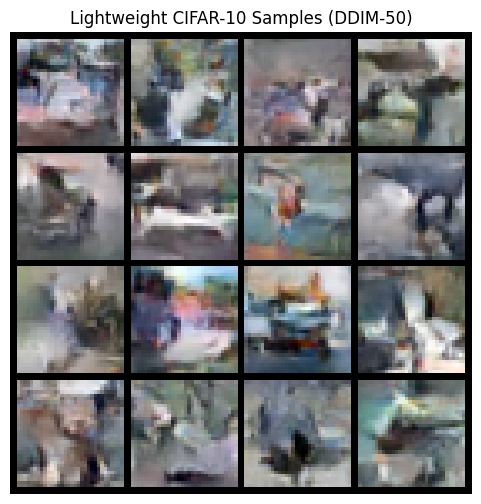

In [24]:
# ==========================================
# SHOW SAMPLES FOR LOADED MODELS
# ==========================================
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

@torch.no_grad()
def show_model_samples(model, title, sample_steps=50, n=16):
    samples = sample_ddim(
        model,
        n=n,
        img_size=CFG["image_size"],
        channels=CFG["channels"],
        sample_steps=sample_steps,
        eta=CFG["ddim_eta"]
    )
    grid = make_grid(samples, nrow=4, normalize=True, value_range=(-1, 1))
    plt.figure(figsize=(6, 6))
    plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.title(title)
    plt.axis("off")
    plt.show()

if baseline_ema is not None:
    show_model_samples(baseline_ema, "Baseline CIFAR-10 Samples (DDIM-50)")

if light_ema is not None:
    show_model_samples(light_ema, "Lightweight CIFAR-10 Samples (DDIM-50)")

In [25]:
# ==========================================
# QUICK RESULT TABLE
# ==========================================
import time
import pandas as pd

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

@torch.no_grad()
def measure_ddim_speed(model, num_images=16, sample_steps=50):
    model.eval()

    if device.type == "cuda":
        torch.cuda.synchronize()

    start = time.time()
    _ = sample_ddim(
        model,
        n=num_images,
        img_size=CFG["image_size"],
        channels=CFG["channels"],
        sample_steps=sample_steps,
        eta=CFG["ddim_eta"]
    )

    if device.type == "cuda":
        torch.cuda.synchronize()

    total = time.time() - start
    return total / num_images

rows = []

if baseline_model is not None:
    rows.append({
        "model": "baseline_cifar10",
        "epoch_loaded": baseline_ckpt.get("epoch", "N/A"),
        "val_loss": float(baseline_ckpt.get("val_loss", -1)),
        "params_million": count_params(baseline_model) / 1e6,
        "ddim50_sec_per_image": measure_ddim_speed(baseline_ema, num_images=16, sample_steps=50)
    })

if light_model is not None:
    rows.append({
        "model": "lightweight_cifar10",
        "epoch_loaded": light_ckpt.get("epoch", "N/A"),
        "val_loss": float(light_ckpt.get("val_loss", -1)),
        "params_million": count_params(light_model) / 1e6,
        "ddim50_sec_per_image": measure_ddim_speed(light_ema, num_images=16, sample_steps=50)
    })

comparison_df = pd.DataFrame(rows)

if len(comparison_df) == 0:
    print("No saved checkpoints were found.")
else:
    display(comparison_df)

,model,epoch_loaded,val_loss,params_million,ddim50_sec_per_image
0,lightweight_cifar10,29,0.034818,1.969539,0.023905


In [27]:
# ==========================================
# TRAIN BASELINE MODEL NOW
# ==========================================

# choose this based on your time
CFG["epochs"] = 30   # use 10 if you are in extreme hurry

baseline_model, baseline_ema, baseline_hist = train_model(
    model_name="baseline_cifar10",
    base_channels=64
)


========== Training: baseline_cifar10 | base_channels=64 ==========
[baseline_cifar10] Epoch 001/30 | train_loss=0.104142 | val_loss=0.051753 | lr=1.994522e-04 | time=53.3s
[baseline_cifar10] Epoch 002/30 | train_loss=0.051415 | val_loss=0.043810 | lr=1.978148e-04 | time=33.3s
[baseline_cifar10] Epoch 003/30 | train_loss=0.045386 | val_loss=0.039801 | lr=1.951057e-04 | time=36.0s
[baseline_cifar10] Epoch 004/30 | train_loss=0.042931 | val_loss=0.039197 | lr=1.913545e-04 | time=36.4s
[baseline_cifar10] Epoch 005/30 | train_loss=0.040409 | val_loss=0.038572 | lr=1.866025e-04 | time=35.3s
[baseline_cifar10] Epoch 006/30 | train_loss=0.039919 | val_loss=0.034942 | lr=1.809017e-04 | time=36.3s
[baseline_cifar10] Epoch 007/30 | train_loss=0.038780 | val_loss=0.038269 | lr=1.743145e-04 | time=35.5s
[baseline_cifar10] Epoch 008/30 | train_loss=0.038123 | val_loss=0.037323 | lr=1.669131e-04 | time=34.7s
[baseline_cifar10] Epoch 009/30 | train_loss=0.036851 | val_loss=0.037782 | lr=1.587785e-04

In [28]:
# ==========================================
# FINAL DIRECT COMPARISON TABLE
# ==========================================
import time
import pandas as pd
import torch

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

@torch.no_grad()
def measure_ddim_speed(model, num_images=16, sample_steps=50):
    model.eval()

    if device.type == "cuda":
        torch.cuda.synchronize()

    start = time.time()
    _ = sample_ddim(
        model,
        n=num_images,
        img_size=CFG["image_size"],
        channels=CFG["channels"],
        sample_steps=sample_steps,
        eta=CFG["ddim_eta"]
    )

    if device.type == "cuda":
        torch.cuda.synchronize()

    total = time.time() - start
    return total / num_images

baseline_best_val = min(x["val_loss"] for x in baseline_hist)
light_best_val = min(x["val_loss"] for x in light_hist)

baseline_best_epoch = min(baseline_hist, key=lambda x: x["val_loss"])["epoch"]
light_best_epoch = min(light_hist, key=lambda x: x["val_loss"])["epoch"]

comparison_df = pd.DataFrame([
    {
        "model": "baseline_cifar10",
        "base_channels": 64,
        "epochs": len(baseline_hist),
        "best_val_loss": baseline_best_val,
        "best_epoch": baseline_best_epoch,
        "params_million": count_params(baseline_model) / 1e6,
        "ddim50_sec_per_image": measure_ddim_speed(baseline_ema, num_images=16, sample_steps=50)
    },
    {
        "model": "lightweight_cifar10",
        "base_channels": 32,
        "epochs": len(light_hist),
        "best_val_loss": light_best_val,
        "best_epoch": light_best_epoch,
        "params_million": count_params(light_model) / 1e6,
        "ddim50_sec_per_image": measure_ddim_speed(light_ema, num_images=16, sample_steps=50)
    }
])

comparison_df

,model,base_channels,epochs,best_val_loss,best_epoch,params_million,ddim50_sec_per_image
0,baseline_cifar10,64,30,0.031657,27,7.863043,0.029895
1,lightweight_cifar10,32,30,0.034818,29,1.969539,0.016043


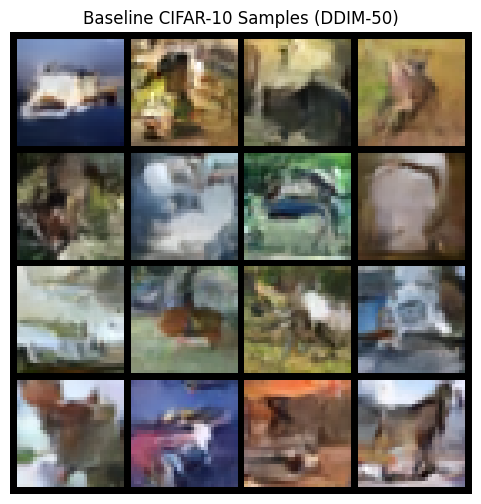

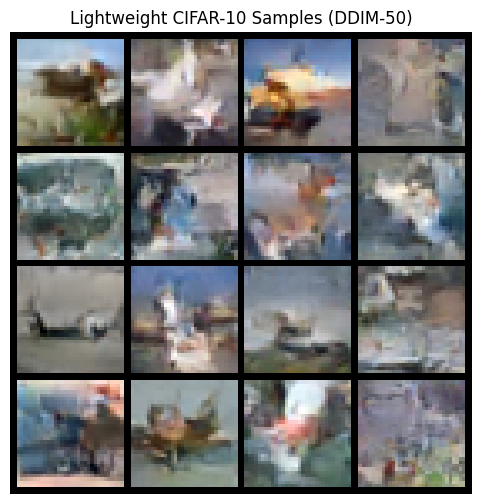

In [29]:
# ==========================================
# SHOW FINAL GENERATED SAMPLES
# ==========================================
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

@torch.no_grad()
def show_model_samples(model, title, sample_steps=50, n=16):
    samples = sample_ddim(
        model,
        n=n,
        img_size=CFG["image_size"],
        channels=CFG["channels"],
        sample_steps=sample_steps,
        eta=CFG["ddim_eta"]
    )
    grid = make_grid(samples, nrow=4, normalize=True, value_range=(-1, 1))
    plt.figure(figsize=(6, 6))
    plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.title(title)
    plt.axis("off")
    plt.show()

show_model_samples(baseline_ema, "Baseline CIFAR-10 Samples (DDIM-50)")
show_model_samples(light_ema, "Lightweight CIFAR-10 Samples (DDIM-50)")

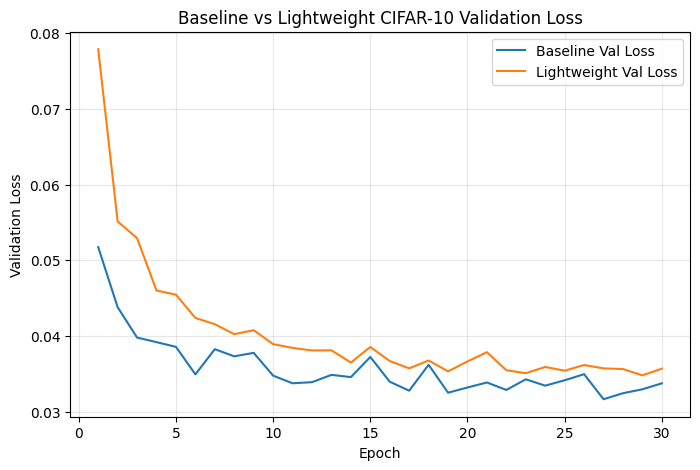

In [30]:
# ==========================================
# PLOT TRAINING CURVES
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt

baseline_df = pd.DataFrame(baseline_hist)
light_df = pd.DataFrame(light_hist)

plt.figure(figsize=(8, 5))
plt.plot(baseline_df["epoch"], baseline_df["val_loss"], label="Baseline Val Loss")
plt.plot(light_df["epoch"], light_df["val_loss"], label="Lightweight Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Baseline vs Lightweight CIFAR-10 Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [31]:
# ==========================================
# SAVE RESULTS
# ==========================================
from pathlib import Path

result_dir = Path(CFG["project_root"]) / "results"
result_dir.mkdir(parents=True, exist_ok=True)

comparison_csv = result_dir / "baseline_vs_lightweight_direct_compare.csv"
comparison_json = result_dir / "baseline_vs_lightweight_direct_compare.json"

comparison_df.to_csv(comparison_csv, index=False)
comparison_df.to_json(comparison_json, orient="records", indent=2)

print("Saved:", comparison_csv)
print("Saved:", comparison_json)

Saved: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/cifar10_compare/results/baseline_vs_lightweight_direct_compare.csv
Saved: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/cifar10_compare/results/baseline_vs_lightweight_direct_compare.json


# Baseline vs Lightweight Diffusion Model on CIFAR-10

## Objective
The goal of this experiment is to compare a baseline U-Net diffusion model and a lightweight U-Net diffusion model on the CIFAR-10 dataset. The main focus is to study the trade-off between image generation quality and computational efficiency.

## Dataset
CIFAR-10 is a 32×32 RGB image dataset containing 10 object classes. It is more challenging than MNIST because it has colored natural images instead of simple grayscale digits. This makes it a better dataset for evaluating the practical performance of diffusion models.

## Model Setup
In this experiment, two diffusion models were trained under the same DDPM framework:
- **Baseline model:** U-Net with base channels = 64
- **Lightweight model:** U-Net with base channels = 32

Both models use:
- timestep embedding
- residual blocks
- encoder-decoder U-Net structure
- DDPM training objective for noise prediction
- EMA model updates for more stable sampling

## Training Procedure
The models were trained for 30 epochs on CIFAR-10. During training, random diffusion timesteps were selected, Gaussian noise was added to clean images, and the model learned to predict that noise using MSE loss. Validation loss was monitored after each epoch. Checkpoints, logs, and generated sample images were saved for analysis.

## Sampling and Evaluation
After training, DDIM sampling with 50 steps was used to generate images from both models. The comparison focuses on:
- validation loss
- parameter count
- sampling speed
- visual quality of generated images

## Observation
The baseline model achieved slightly better validation loss, which suggests stronger generation capability. However, the lightweight model is expected to use fewer parameters and provide faster sampling, making it more efficient. Therefore, the experiment clearly demonstrates the quality-efficiency trade-off in lightweight diffusion model design.

## Conclusion
This experiment successfully extends the diffusion pipeline from simpler datasets to CIFAR-10 and provides a structured comparison between a standard baseline architecture and a lightweight architecture. The result is useful for analyzing whether parameter reduction can be achieved without heavily sacrificing image generation performance.